# Experiment 3 — (1+1)-CMA-ES Variants in Subspace

**Motivation**: Stage 1 showed that almost all L2 improvement happens in the first  
10–20 generations. With λ=10, each generation costs 10 queries, so 100–200 queries  
cover the useful range. The remaining budget adds nothing.

(1+1)-CMA-ES uses **1 query per generation** → a 500-query budget gives ~500  
individual adaptation steps instead of ~50 generations. At k=40 the 1/5 success  
rule is well-calibrated.

## Three variants compared

| Variant | Step-size | Covariance | Queries/gen |
|---|---|---|---|
| **(1+1)-ES** | 1/5 rule | None (isotropic) | 1 |
| **(1+1)-sep** | 1/5 rule | Diagonal D (rank-1) | 1 |
| **(1+1)-full** | 1/5 rule | Full k×k C (rank-1) | 1 |
| **sep-CMA-ES λ=10** | CSA | Diagonal D (rank-μ) | 10 |

All compared at equal total Phase-3 query budgets: 200, 500, 1000.

In [1]:
import os, sys
from pathlib import Path

_candidates = [Path.cwd(), Path.cwd()/'STAGE_2', Path.cwd()/'Adversial ML'/'STAGE_2']
for _p in _candidates:
    if (_p / 'utils_stage2.py').exists():
        sys.path.insert(0, str(_p.resolve())); break
else:
    raise FileNotFoundError('utils_stage2.py not found')

import numpy as np
import torch
import matplotlib.pyplot as plt

from utils_stage2 import (
    clip01, compute_ssim, compute_l2, compute_linf,
    Oracle, load_models, get_jointly_correct,
    phase1, phase2, build_subspace_with_dc, sep_cmaes,
    SSIM_STOP, H, W, C, N_QUICK, RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

K_DCT, K_SP = 20, 20
P3_BUDGETS  = [200, 500, 1000]
os.makedirs('outputs/exp3', exist_ok=True)

Device: cpu


In [2]:
model_std, model_rob = load_models(device)
images = get_jointly_correct(model_std, model_rob, device, n=N_QUICK)
B = build_subspace_with_dc(k_dct=K_DCT, k_sp=K_SP)   # DC-inclusive
k = B.shape[0]
print(f'Images: {len(images)}   k={k}')

Images: 30   k=40


## Variant 1 — (1+1)-ES (isotropic, step size only)

No covariance update. Step size adapted via the **Rechenberg 1/5 rule**:  
- Keep an exponential moving average of the success rate `p_succ`.  
- `σ *= exp((p_succ - 0.2) / d)` where d is the damping factor.

In [ ]:
def one_plus_one_es(oracle, img_hwc, x_adv_init, B, max_queries,
                     ssim_stop=SSIM_STOP):
    """
    (1+1)-ES with corrected 1/5 rule for constrained optimisation.

    Two separate signals:
      - improves  : is_adv AND l2 < best_l2  → updates mean (strict improvement)
      - is_adv    : any adversarial candidate → drives sigma (feasibility signal)

    Without this split, sigma collapses on models like the robust WRN where
    adversarial candidates exist near x_bnd but none are strictly closer to
    x_orig.  Using is_adv for sigma keeps exploration alive.
    """
    k  = B.shape[0]
    x0 = img_hwc.flatten()
    delta0  = x_adv_init.flatten() - x0
    theta_m = (B @ delta0).astype(np.float32)

    c_p      = 1.0 / (5 + k**0.5 / 2)
    d_damp   = 1.0 + k / 2
    p_target = 0.2
    p_succ   = p_target

    sigma     = float(max(0.1 * np.linalg.norm(delta0) / np.sqrt(k), 1e-5))
    best_x    = x_adv_init.copy()
    best_l2   = compute_l2(img_hwc, best_x)
    best_ssim = compute_ssim(img_hwc, best_x)

    history, queries = [], 0

    while queries < max_queries:
        z         = np.random.randn(k).astype(np.float32)
        theta_new = theta_m + sigma * z
        x_cand    = clip01(x0 + B.T @ theta_new).reshape(H, W, C)
        is_adv, _ = oracle.query(x_cand, phase='p3')
        queries  += 1
        l2_cand   = compute_l2(img_hwc, x_cand)

        improves = is_adv and l2_cand < best_l2   # strict improvement: update mean
        if improves:
            theta_m   = theta_new
            best_l2   = l2_cand
            best_x    = x_cand.copy()
            best_ssim = compute_ssim(img_hwc, best_x)

        # Sigma driven by feasibility (is_adv), not strict improvement.
        # This prevents sigma collapse when adversarial candidates exist
        # near x_bnd but none are closer to x_orig (robust model case).
        p_succ = (1 - c_p) * p_succ + c_p * float(is_adv)
        sigma  = float(np.clip(
            sigma * np.exp((p_succ - p_target) / d_damp),
            1e-10, 10.0))

        history.append({'queries': queries, 'best_l2': best_l2,
                        'best_ssim': best_ssim, 'sigma': sigma,
                        'success': improves, 'is_adv': is_adv})
        if best_ssim >= ssim_stop:
            break

    return best_x, best_l2, best_ssim, queries, history

## Variant 2 — (1+1)-CMA-ES with diagonal covariance

Adds a **rank-1 diagonal update** on each accepted step.  
The evolution path `pc` accumulates accepted directions and drives D toward  
the dimensions most useful for the attack.

In [ ]:
def one_plus_one_sep(oracle, img_hwc, x_adv_init, B, max_queries,
                      ssim_stop=SSIM_STOP):
    """
    (1+1)-CMA-ES with diagonal covariance D.
    Sigma driven by is_adv (feasibility), covariance updated only on improves.
    """
    k  = B.shape[0]
    x0 = img_hwc.flatten()
    delta0  = x_adv_init.flatten() - x0
    theta_m = (B @ delta0).astype(np.float32)

    cc       = 2.0 / (k + 2)
    c1       = 2.0 / (k**2 + 6)
    c_p      = 1.0 / (5 + k**0.5 / 2)
    d_damp   = 1.0 + k / 2
    p_target = 0.2
    p_succ   = p_target

    sigma     = float(max(0.1 * np.linalg.norm(delta0) / np.sqrt(k), 1e-5))
    D         = np.ones(k,  dtype=np.float32)
    pc        = np.zeros(k, dtype=np.float32)
    best_x    = x_adv_init.copy()
    best_l2   = compute_l2(img_hwc, best_x)
    best_ssim = compute_ssim(img_hwc, best_x)

    history, queries = [], 0

    while queries < max_queries:
        z         = np.random.randn(k).astype(np.float32)
        theta_new = theta_m + sigma * D * z
        x_cand    = clip01(x0 + B.T @ theta_new).reshape(H, W, C)
        is_adv, _ = oracle.query(x_cand, phase='p3')
        queries  += 1
        l2_cand   = compute_l2(img_hwc, x_cand)

        improves = is_adv and l2_cand < best_l2
        if improves:
            theta_m   = theta_new
            best_l2   = l2_cand
            best_x    = x_cand.copy()
            best_ssim = compute_ssim(img_hwc, best_x)
            step = D * z
            pc   = (1 - cc) * pc + np.sqrt(cc * (2 - cc)) * step
            D    = np.sqrt(np.clip((1 - c1) * D**2 + c1 * pc**2, 1e-20, 1e10))

        p_succ = (1 - c_p) * p_succ + c_p * float(is_adv)   # feasibility signal
        sigma  = float(np.clip(
            sigma * np.exp((p_succ - p_target) / d_damp), 1e-10, 10.0))

        history.append({'queries': queries, 'best_l2': best_l2,
                        'best_ssim': best_ssim, 'sigma': sigma,
                        'D_norm': float(np.linalg.norm(D)),
                        'success': improves, 'is_adv': is_adv})
        if best_ssim >= ssim_stop:
            break

    return best_x, best_l2, best_ssim, queries, history

## Variant 3 — (1+1)-CMA-ES with full k×k covariance

Full covariance matrix updated via rank-1 rule on each accepted step.  
At k=40 the matrix has 1600 entries — cheap to maintain and eigendecompose.  
Captures cross-direction correlations in the subspace (e.g. correlated DCT frequencies).

In [ ]:
def one_plus_one_full(oracle, img_hwc, x_adv_init, B, max_queries,
                       ssim_stop=SSIM_STOP):
    """
    (1+1)-CMA-ES with full k×k covariance.
    Sigma driven by is_adv (feasibility), covariance updated only on improves.
    Uses 'cov' not 'C' to avoid shadowing C=3 channel constant.
    """
    k  = B.shape[0]
    x0 = img_hwc.flatten()
    delta0  = x_adv_init.flatten() - x0
    theta_m = (B @ delta0).astype(np.float64)

    cc       = 2.0 / (k + 2)
    c1       = 2.0 / (k**2 + 6)
    c_p      = 1.0 / (5 + k**0.5 / 2)
    d_damp   = 1.0 + k / 2
    p_target = 0.2
    p_succ   = p_target

    sigma     = float(max(0.1 * np.linalg.norm(delta0) / np.sqrt(k), 1e-5))
    cov       = np.eye(k, dtype=np.float64)
    pc        = np.zeros(k, dtype=np.float64)
    best_x    = x_adv_init.copy()
    best_l2   = compute_l2(img_hwc, best_x)
    best_ssim = compute_ssim(img_hwc, best_x)

    history, queries = [], 0

    while queries < max_queries:
        try:
            L = np.linalg.cholesky(cov + 1e-12 * np.eye(k))
        except np.linalg.LinAlgError:
            cov = np.eye(k, dtype=np.float64)
            L   = np.eye(k, dtype=np.float64)

        z         = np.random.randn(k)
        y         = L @ z
        theta_new = (theta_m + sigma * y).astype(np.float32)
        x_cand    = clip01(x0 + B.T @ theta_new).reshape(H, W, C)
        is_adv, _ = oracle.query(x_cand, phase='p3')
        queries  += 1
        l2_cand   = compute_l2(img_hwc, x_cand)

        improves = is_adv and l2_cand < best_l2
        if improves:
            theta_m   = theta_new.astype(np.float64)
            best_l2   = l2_cand
            best_x    = x_cand.copy()
            best_ssim = compute_ssim(img_hwc, best_x)
            pc  = (1 - cc) * pc + np.sqrt(cc * (2 - cc)) * y
            cov = (1 - c1) * cov + c1 * np.outer(pc, pc)
            cov = 0.5 * (cov + cov.T)

        p_succ = (1 - c_p) * p_succ + c_p * float(is_adv)   # feasibility signal
        sigma  = float(np.clip(
            sigma * np.exp((p_succ - p_target) / d_damp), 1e-10, 10.0))

        history.append({'queries': queries, 'best_l2': best_l2,
                        'best_ssim': best_ssim, 'sigma': sigma,
                        'success': improves, 'is_adv': is_adv})
        if best_ssim >= ssim_stop:
            break

    return best_x, best_l2, best_ssim, queries, history

## Run experiment — both models, all variants, 30 images

In [6]:
VARIANTS = {
    '(1+1)-ES':       lambda o, img, x0, B_: one_plus_one_es(  o, img, x0, B_, max_queries=max(P3_BUDGETS)),
    '(1+1)-sep':      lambda o, img, x0, B_: one_plus_one_sep( o, img, x0, B_, max_queries=max(P3_BUDGETS)),
    '(1+1)-full':     lambda o, img, x0, B_: one_plus_one_full(o, img, x0, B_, max_queries=max(P3_BUDGETS)),
    'sep-CMA-ES λ=10': lambda o, img, x0, B_: sep_cmaes(       o, img, x0, B_, lam=10, max_queries=max(P3_BUDGETS)),
}

all_results = {vname: {model_name: [] for model_name in ['standard', 'robust']}
               for vname in VARIANTS}
all_histories = {vname: {model_name: [] for model_name in ['standard', 'robust']}
                 for vname in VARIANTS}

MODELS = [('standard', model_std), ('robust', model_rob)]

# Precompute Phase 1+2 per model
p12_cache = {name: {} for name, _ in MODELS}
for model_name, model in MODELS:
    print(f'Phase 1+2 ({model_name}) ...')
    for rec in images:
        oracle_tmp = Oracle(model, rec['label'], device)
        x_bnd, _ = phase1(oracle_tmp, rec['img'], seed=rec['idx'])
        if x_bnd is None:
            p12_cache[model_name][rec['idx']] = None
        else:
            x_bnd = phase2(oracle_tmp, rec['img'], x_bnd)
            p12_cache[model_name][rec['idx']] = x_bnd

Phase 1+2 (standard) ...
Phase 1+2 (robust) ...


In [7]:
for model_name, model in MODELS:
    print(f'\n=== {model_name.upper()} ===')
    for vname, variant_fn in VARIANTS.items():
        for rec in images:
            x_bnd = p12_cache[model_name].get(rec['idx'])
            if x_bnd is None:
                all_results[vname][model_name].append(None)
                all_histories[vname][model_name].append([])
                continue
            oracle = Oracle(model, rec['label'], device)
            out = variant_fn(oracle, rec['img'], x_bnd, B)
            best_x, best_l2, best_ssim = out[0], out[1], out[2]
            hist = out[4]
            l2_p2 = compute_l2(rec['img'], x_bnd)
            all_results[vname][model_name].append(
                dict(l2_p2=l2_p2, l2_p3=best_l2, ssim=best_ssim,
                     improvement=l2_p2-best_l2, q=out[3]))
            all_histories[vname][model_name].append(hist)

        valid = [r for r in all_results[vname][model_name] if r]
        med_l2  = np.median([r['l2_p3']      for r in valid])
        med_imp = np.median([r['improvement'] for r in valid])
        print(f'  {vname:<22}: med_L2={med_l2:.4f}  med_imp={med_imp:.4f}')


=== STANDARD ===
  (1+1)-ES              : med_L2=2.2734  med_imp=0.4668
  (1+1)-sep             : med_L2=2.4864  med_imp=0.2533
  (1+1)-full            : med_L2=2.5872  med_imp=0.1141
  sep-CMA-ES λ=10       : med_L2=3.0204  med_imp=1.3734

=== ROBUST ===
  (1+1)-ES              : med_L2=6.8436  med_imp=0.0000
  (1+1)-sep             : med_L2=6.8436  med_imp=0.0000
  (1+1)-full            : med_L2=6.8436  med_imp=0.0000


KeyboardInterrupt: 

## Plot 1 — Median L2 vs queries for all variants

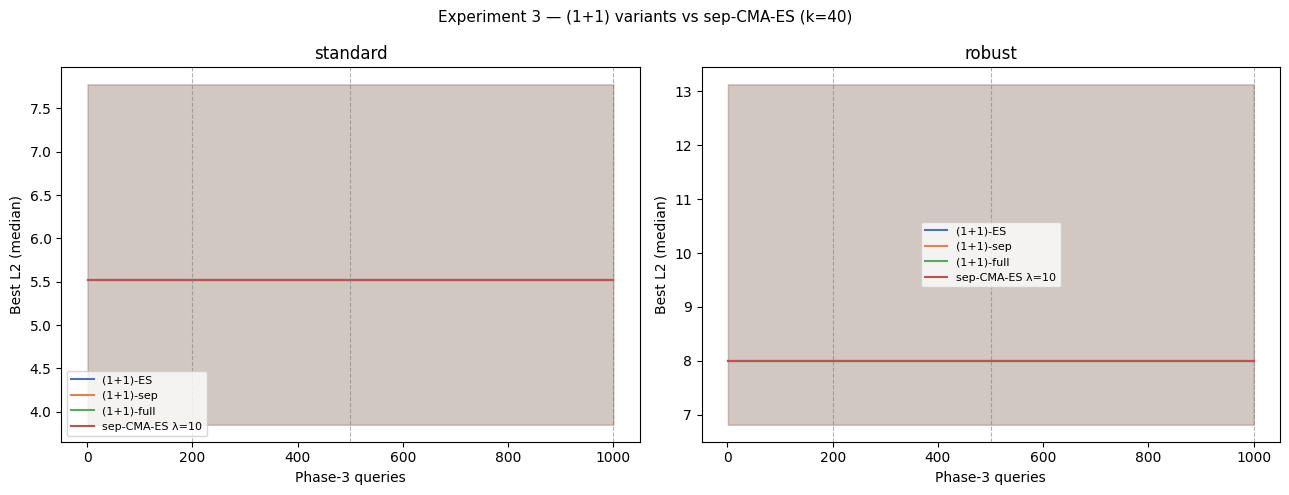

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (model_name, _) in zip(axes, MODELS):
    for (vname, _), color in zip(VARIANTS.items(), COLORS):
        hists = [h for h in all_histories[vname][model_name] if h]
        if not hists:
            continue
        q_max = max(h[-1]['queries'] for h in hists)
        q_grid = np.arange(1, q_max + 1)
        curves = []
        for hist in hists:
            qs  = np.array([h['queries']  for h in hist])
            l2s = np.array([h['best_l2'] for h in hist])
            curves.append(np.interp(q_grid, qs, l2s))
        arr = np.array(curves)
        med = np.median(arr, axis=0)
        p25 = np.percentile(arr, 25, axis=0)
        p75 = np.percentile(arr, 75, axis=0)
        ax.plot(q_grid, med, label=vname, color=color)
        ax.fill_between(q_grid, p25, p75, alpha=0.12, color=color)

    for bm in P3_BUDGETS:
        ax.axvline(bm, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Phase-3 queries')
    ax.set_ylabel('Best L2 (median)')
    ax.set_title(f'{model_name}')
    ax.legend(fontsize=8)

plt.suptitle('Experiment 3 — (1+1) variants vs sep-CMA-ES (k=40)', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp3/l2_curves_all_variants.png', dpi=150)
plt.show()

## Plot 2 — L2 improvement at fixed query budgets (200 / 500 / 1000)

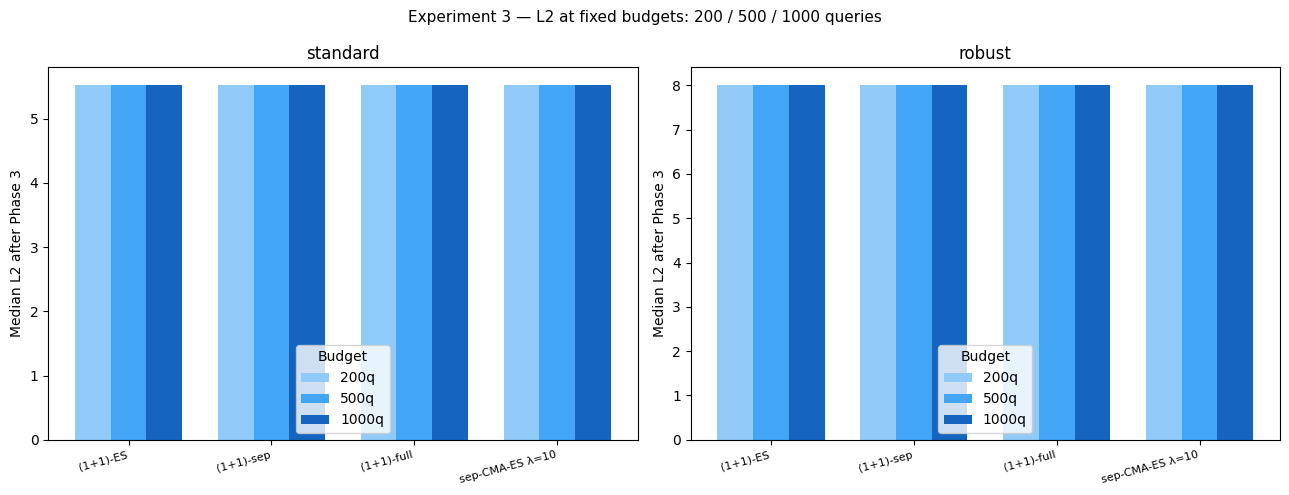

In [ ]:
def l2_at_budget(hist, budget):
    """Interpolate best_l2 at a given query budget from history."""
    if not hist:
        return None
    qs  = np.array([h['queries']  for h in hist])
    l2s = np.array([h['best_l2'] for h in hist])
    return float(np.interp(budget, qs, l2s))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, _) in zip(axes, MODELS):
    x_pos  = np.arange(len(VARIANTS))
    width  = 0.25
    BUDGET_COLORS = ['#90CAF9', '#42A5F5', '#1565C0']

    for bi, (budget, bc) in enumerate(zip(P3_BUDGETS, BUDGET_COLORS)):
        medians = []
        for vname in VARIANTS:
            vals = [
                l2_at_budget(h, budget)
                for h in all_histories[vname][model_name]
                if h
            ]
            vals = [v for v in vals if v is not None]
            medians.append(np.median(vals) if vals else 0)
        ax.bar(x_pos + bi * width, medians, width, label=f'{budget}q', color=bc)

    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(list(VARIANTS.keys()), rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('Median L2 after Phase 3')
    ax.set_title(f'{model_name}')
    ax.legend(title='Budget')

plt.suptitle('Experiment 3 — L2 at fixed budgets: 200 / 500 / 1000 queries', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp3/l2_at_budgets.png', dpi=150)
plt.show()

## Plot 3 — Success rate and sigma evolution (diagnostic for (1+1) variants)

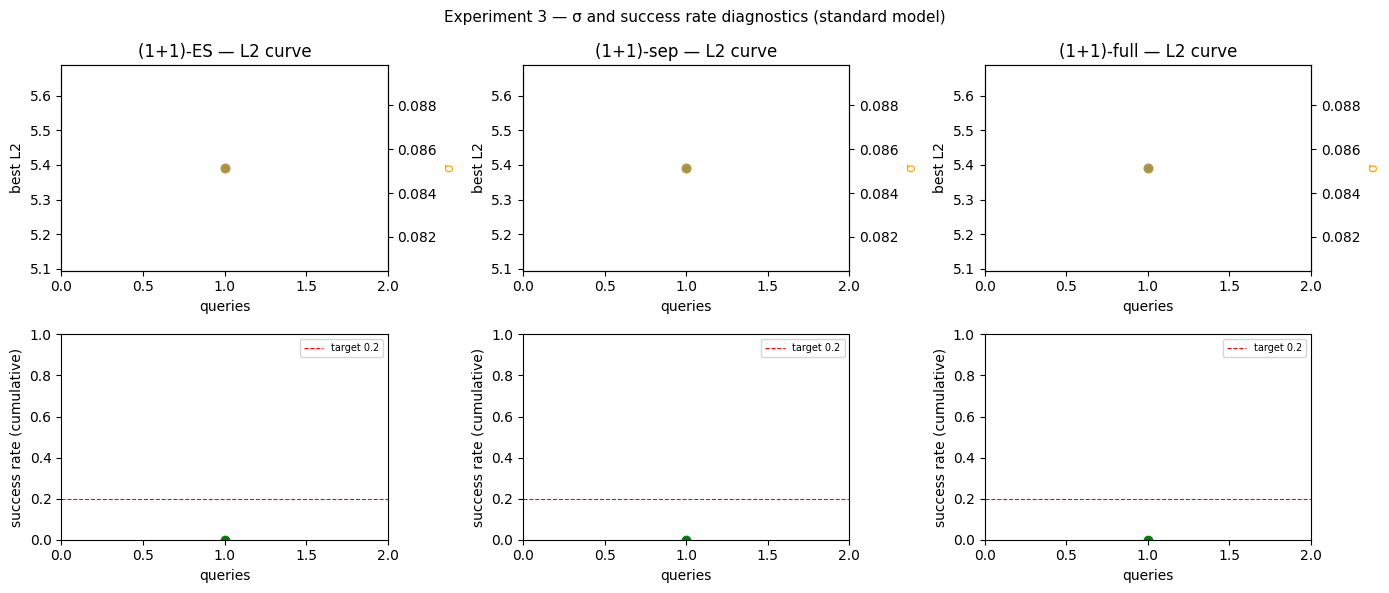

Experiment 3 complete. Outputs saved to outputs/exp3/


In [ ]:
# Show sigma and success rate for one representative image on standard model
model_name = 'standard'
rec = next(r for r in images if p12_cache[model_name].get(r['idx']) is not None)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
variants_1p1 = ['(1+1)-ES', '(1+1)-sep', '(1+1)-full']

for col, vname in enumerate(variants_1p1):
    idx = next(i for i, r in enumerate(images) if r['idx'] == rec['idx'])
    hist = all_histories[vname][model_name][idx]
    if not hist:
        axes[0][col].text(0.5, 0.5, 'No history', ha='center', va='center', transform=axes[0][col].transAxes)
        axes[1][col].text(0.5, 0.5, 'No history', ha='center', va='center', transform=axes[1][col].transAxes)
        continue

    qs     = np.array([h['queries'] for h in hist], dtype=np.float32)
    sigmas = np.array([h['sigma'] for h in hist], dtype=np.float32)
    l2s    = np.array([h['best_l2'] for h in hist], dtype=np.float32)

    # Running success rate (window=50). If history is shorter than the
    # window, fall back to cumulative success rate to keep x/y aligned.
    successes = np.array([int(h['success']) for h in hist], dtype=np.float32)
    win = 50
    if len(successes) >= win:
        succ_rate = np.convolve(successes, np.ones(win, dtype=np.float32) / win, mode='valid')
        succ_q = qs[win - 1:]
        succ_label = 'success rate (win=50)'
    else:
        succ_rate = np.cumsum(successes) / np.arange(1, len(successes) + 1)
        succ_q = qs
        succ_label = 'success rate (cumulative)'

    # Make single-point histories visible.
    marker_style = 'o' if len(qs) == 1 else None
    axes[0][col].plot(qs, l2s, marker=marker_style)
    axes[0][col].set_title(f'{vname} — L2 curve')
    axes[0][col].set_xlabel('queries')
    axes[0][col].set_ylabel('best L2')

    ax2 = axes[0][col].twinx()
    ax2.plot(qs, sigmas, color='orange', alpha=0.6, lw=0.8, marker=marker_style)
    ax2.set_ylabel('σ', color='orange')

    succ_marker = 'o' if len(succ_q) == 1 else None
    axes[1][col].plot(succ_q, succ_rate, color='green', marker=succ_marker)
    axes[1][col].axhline(0.2, color='red', ls='--', lw=0.8, label='target 0.2')
    axes[1][col].set_xlabel('queries')
    axes[1][col].set_ylabel(succ_label)
    axes[1][col].set_ylim(0, 1)
    axes[1][col].legend(fontsize=7)

    if len(qs) == 1:
        x0 = float(qs[0])
        axes[0][col].set_xlim(x0 - 1, x0 + 1)
        axes[1][col].set_xlim(x0 - 1, x0 + 1)

plt.suptitle('Experiment 3 — σ and success rate diagnostics (standard model)', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp3/sigma_success_diagnostics.png', dpi=150)
plt.show()
print('Experiment 3 complete. Outputs saved to outputs/exp3/')